In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# for better visuals
plt.style.use('seaborn-v0_8')

# load data
df = pd.read_csv('../data/city_day.csv')

df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [2]:
# filter Bangalore data
blr_df = df[df['City'] == 'Bengaluru'].copy()

blr_df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
4294,Bengaluru,2015-01-01,NaN,NaN,3.26,17.33,10.88,20.36,0.33,3.54,10.73,0.56,4.64,NaN,NaN,NaN
4295,Bengaluru,2015-01-02,NaN,NaN,6.05,19.73,14.14,23.74,1.35,3.97,22.77,0.65,5.31,NaN,NaN,NaN
4296,Bengaluru,2015-01-03,NaN,NaN,11.91,19.88,20.72,4.32,17.40,13.61,12.03,0.53,19.25,NaN,NaN,NaN
4297,Bengaluru,2015-01-04,NaN,NaN,7.45,21.61,16.88,0.87,5.05,6.52,17.70,0.55,7.47,NaN,NaN,NaN
4298,Bengaluru,2015-01-05,NaN,NaN,9.52,22.17,21.76,31.38,1.83,4.71,12.72,0.40,4.36,NaN,NaN,NaN


In [3]:
blr_df = blr_df[['Date', 'PM2.5']]

blr_df.head()

,Date,PM2.5
4294,2015-01-01,NaN
4295,2015-01-02,NaN
4296,2015-01-03,NaN
4297,2015-01-04,NaN
4298,2015-01-05,NaN


In [4]:
blr_df['Date'] = pd.to_datetime(blr_df['Date'])
blr_df.set_index('Date', inplace=True)

blr_df.head()

,PM2.5
Date,
2015-01-01,NaN
2015-01-02,NaN
2015-01-03,NaN
2015-01-04,NaN
2015-01-05,NaN


In [5]:
blr_df.isnull().sum()

PM2.5    146
dtype: int64

In [6]:
blr_df = blr_df.dropna()

In [7]:
blr_df.info()
blr_df.describe()

<class 'pandas.DataFrame'>
DatetimeIndex: 1863 entries, 2015-03-20 to 2020-07-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PM2.5   1863 non-null   float64
dtypes: float64(1)
memory usage: 29.1 KB


,PM2.5
count,1863.000000
mean,35.819828
std,22.073252
min,1.720000
25%,21.295000
50%,30.920000
75%,44.250000
max,313.590000


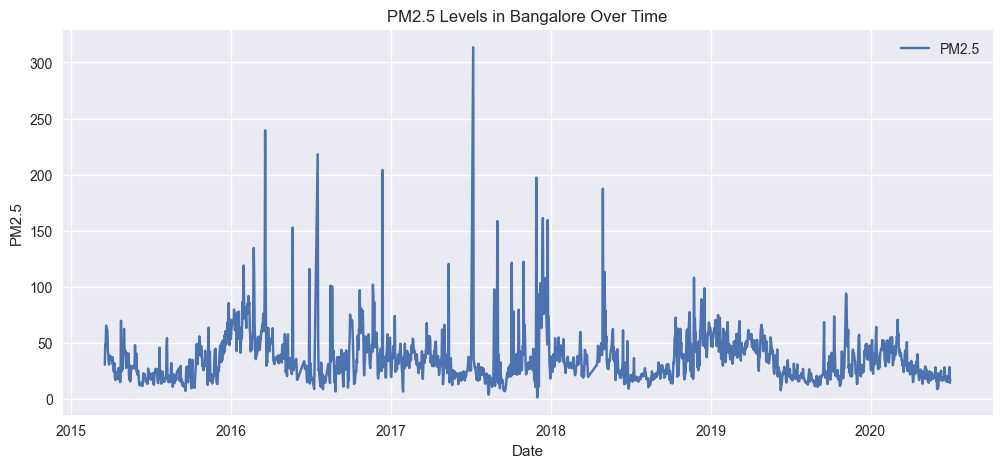

In [8]:
# Plot PM2.5 Trend
plt.figure(figsize=(12,5))
plt.plot(blr_df['PM2.5'], label='PM2.5')
plt.title('PM2.5 Levels in Bangalore Over Time')
plt.xlabel('Date')
plt.ylabel('PM2.5')
plt.legend()
plt.show()

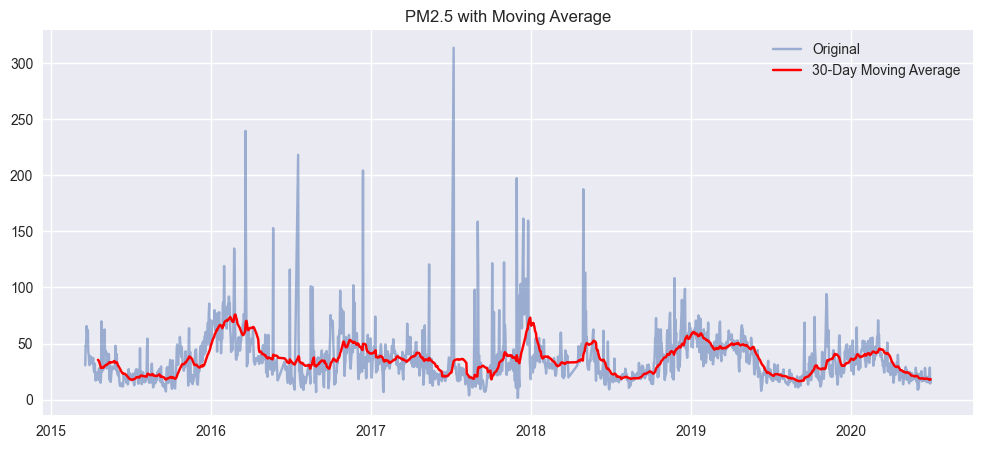

In [9]:
# Moving Average (Smoothing) This helps remove noise and show the trend clearly.

blr_df['MA_30'] = blr_df['PM2.5'].rolling(window=30).mean()

plt.figure(figsize=(12,5))
plt.plot(blr_df['PM2.5'], label='Original', alpha=0.5)
plt.plot(blr_df['MA_30'], label='30-Day Moving Average', color='red')
plt.title('PM2.5 with Moving Average')
plt.legend()
plt.show()

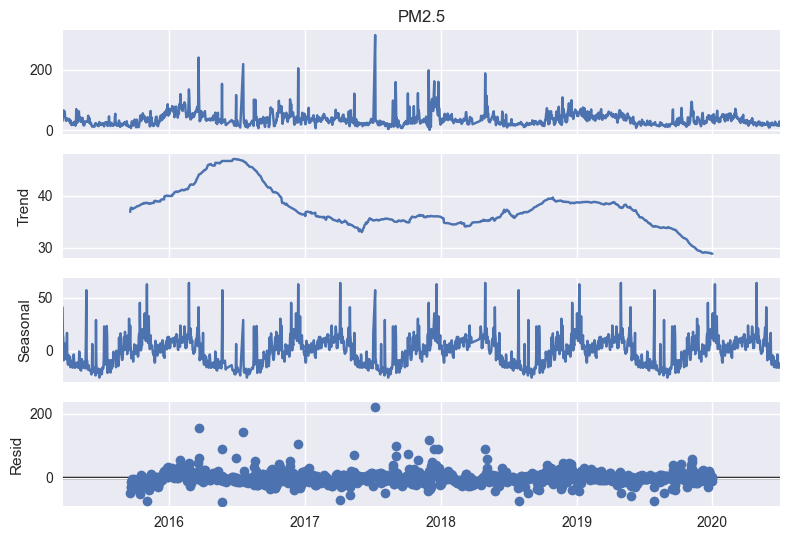

In [10]:
# Time Series Decomposition

from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(blr_df['PM2.5'], model='additive', period=365)

decomposition.plot()
plt.show()

In [11]:
blr_df = blr_df.asfreq('D')
blr_df = blr_df.ffill()

In [12]:
#ADF Test (Original Data)

from statsmodels.tsa.stattools import adfuller

result = adfuller(blr_df['PM2.5'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -5.5792190649618245
p-value: 1.4090887847441197e-06
Critical Values:
1%: -3.433767579644038
5%: -2.8630496663460607
10%: -2.567573687930666


How to Interpret:

  Condition	     Meaning
p-value < 0.05	Stationary
p-value > 0.05	Non-stationary

In [13]:
# Apply Differencing. This removes the trend.
blr_df['PM2.5_diff'] = blr_df['PM2.5'].diff()

blr_df = blr_df.dropna()

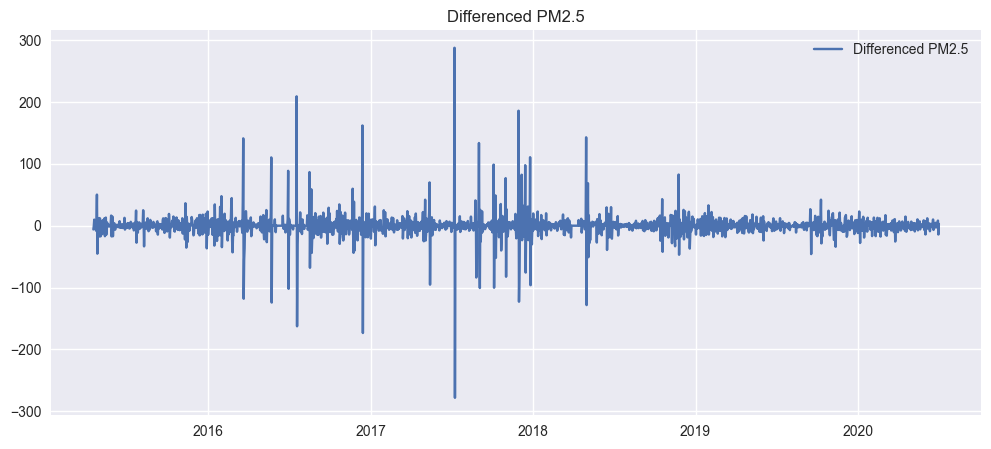

In [14]:
# Plot Differenced Data
plt.figure(figsize=(12,5))
plt.plot(blr_df['PM2.5_diff'], label='Differenced PM2.5')
plt.title('Differenced PM2.5')
plt.legend()
plt.show()

In [15]:
# ADF Test Again
result_diff = adfuller(blr_df['PM2.5_diff'])

print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])

ADF Statistic: -13.718407824051694
p-value: 1.2006614061158526e-25


In [16]:
# Train-Test Split

train_size = int(len(blr_df) * 0.8)

train = blr_df['PM2.5'][:train_size]
test = blr_df['PM2.5'][train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 1521
Test size: 381


In [17]:
# Build ARIMA Model
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(1,0,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  PM2.5   No. Observations:                 1521
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -6668.039
Date:                Mon, 23 Mar 2026   AIC                          13344.079
Time:                        16:27:29   BIC                          13365.387
Sample:                    04-18-2015   HQIC                         13352.011
                         - 06-16-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.9628      3.150     11.736      0.000      30.790      43.136
ar.L1          0.8973      0.015     61.435      0.000       0.869       0.926
ma.L1         -0.5968      0.020    -29.934      0.0

In [18]:
# Make Predictions
predictions = model_fit.forecast(steps=len(test))

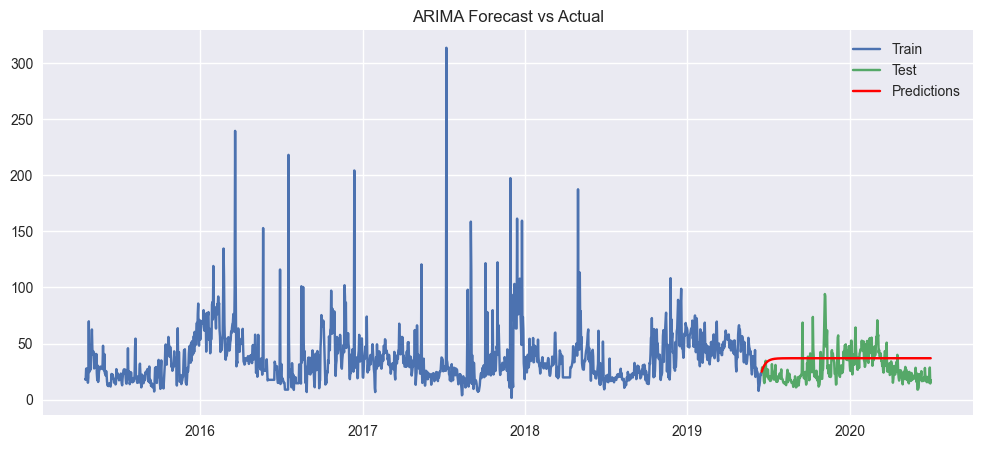

In [19]:
# Plot Results
plt.figure(figsize=(12,5))

plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, predictions, label='Predictions', color='red')

plt.title('ARIMA Forecast vs Actual')
plt.legend()
plt.show()

Model Improvement: 
Now we improve the model using better parameter selection.
We will:
1. Try different ARIMA configurations
2. Compare using AIC
3. Pick better model
4. Generate improved forecast

In [20]:
# Try Multiple ARIMA Models

from statsmodels.tsa.arima.model import ARIMA

orders = [(1,0,1), (2,0,1), (1,0,2), (2,0,2), (3,0,1)]

for order in orders:
    try:
        model = ARIMA(train, order=order)
        result = model.fit()
        print(f"ARIMA{order} → AIC: {result.aic}")
    except:
        continue

ARIMA(1, 0, 1) → AIC: 13344.078667683303
ARIMA(2, 0, 1) → AIC: 13302.085332432758
ARIMA(1, 0, 2) → AIC: 13309.248354525393
ARIMA(2, 0, 2) → AIC: 13302.897256760729
ARIMA(3, 0, 1) → AIC: 13303.088268327556


What You’re Doing is:
- Testing multiple (p,d,q) combinations
- Comparing AIC values
- Lower AIC = better model

In [21]:
#Train Final Model

model = ARIMA(train, order=(2,0,1))
model_fit = model.fit()

In [22]:
# Forecast Again
predictions = model_fit.forecast(steps=len(test))

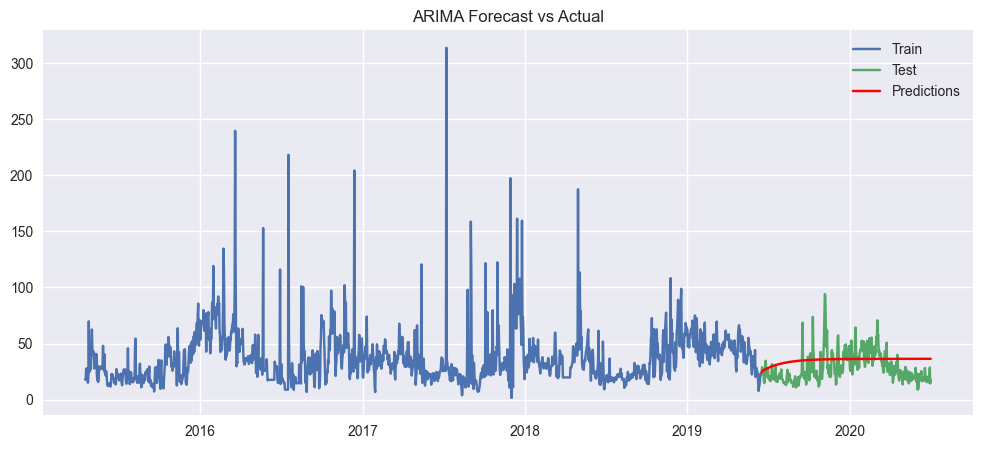

In [23]:
# Plot Again
plt.figure(figsize=(12,5))

plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, predictions, label='Predictions', color='red')

plt.title('ARIMA Forecast vs Actual')
plt.legend()
plt.show()

In [24]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(test, predictions)

print("MAE:", mae)

MAE: 12.131213931138037


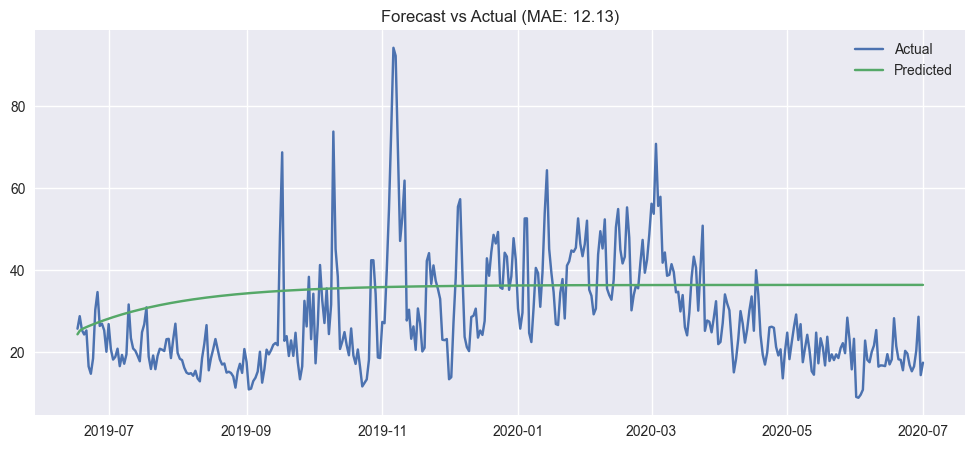

In [25]:
plt.figure(figsize=(12,5))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, predictions, label='Predicted')
plt.title(f'Forecast vs Actual (MAE: {mae:.2f})')
plt.legend()
plt.show()